<a href="https://colab.research.google.com/github/kcf1/fina4359-quant-trading/blob/asm1/fina4359_asm1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pandas_datareader as pdr

# Import macro return data

In [93]:
ret = pd.read_excel('macro_return.xlsx',index_col=0,parse_dates=True)

In [94]:
ret = ret.iloc[18:302,1].astype(float)


Samples 284 months

Annulized
Mean = 17.93%
Std  = 13.35%
Skew = -0.02
SR   = 1.34



<Axes: >

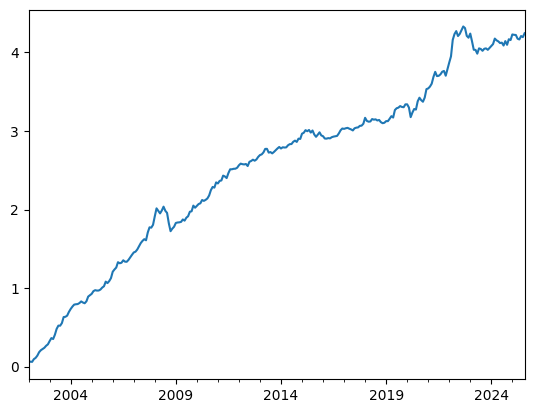

In [95]:
m = ret.mean() * 12
s = ret.std() * 12 ** 0.5
sr = m/s
sk = ret.skew()
print(f'''
Samples {ret.count()} months

Annulized
Mean = {m:.2%}
Std  = {s:.2%}
Skew = {sk:.2f}
SR   = {sr:.2f}
''')
ret.cumsum().plot()

# FF5 Benchmark
Conceptually, not a good benchmark:
- Macro invests in all asset classes (incl. fx, rates, commods, etc.) across regions, while FF5 only covers US equity factors
- FF5 might explain partially, as US equities is in fund's investment universe
---
Reasonable benchmark (alpha on FF5 adds uncorrelated return to their portfolio):
- US pension that primarily invest in US equity
- US big corp that are sensitive to US market cycles (high beta)
---
Inappropriate benchmark:
- Relative performance to macro peers
- Investors with access to global markets (not only US)

In [96]:
import pandas_datareader as pdr
# Fama-French 5 factors (2x3). Returns a list; [0] is the factor returns.
ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]

In [97]:
ff5 = ff5 / 100
ff5.index = ff5.index.to_timestamp() + pd.offsets.MonthEnd(0)

In [98]:
reg_df = ff5.copy()
reg_df['Macro-RF'] = ret - reg_df['RF']
reg_df.dropna(inplace=True)

In [99]:
y = reg_df['Macro-RF']
x = reg_df.drop(columns=['RF','Macro-RF'])

As expected, not a good benchmark:
- FF5 factors did not explained much of the return, resulting in significantly high alpha
- Only US market factor is significant, beta ~0.24, except that HML has a relative small p-value (still insignificant), fund might have some value play
- R^2 is only 10% (90% left unexplained), FF5 failed to track the index properly

In [100]:
model = sm.OLS(y,sm.add_constant(x)).fit()
alpha = model.params['const'] * 12
print(f'Ann. alpha = {alpha:.2%}')
model.summary()

Ann. alpha = 13.90%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Macro-RF   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     6.357
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.31e-05
Time:                        10:38:00   Log-Likelihood:                 536.60
No. Observations:                 284   AIC:                            -1061.
Df Residuals:                     278   BIC:                            -1039.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0116      0.002      5.060      0.000       0.007       0.016
Mkt-RF         0.2396      0.055      4.382      0.000       0.132       0.347
SMB           -0.0036      0.095     -0.038      0.970      -0.191       0.184
HML            0.1321      0.092      1.429      0.154      -0.050       0.314
RMW            0.0155      0.113      0.137      0.891      -0.207       0.238
CMA            0.1562      0.138      1.134      0.258      -0.115       0.427
==============================================================================
Omnibus:                       29.919   Durbin-Watson:                   1.620
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              126.512
Skew:                           0.247   Prob(JB):                     3.37e-28
Kurtosis:                       6.232   Cond. No.                         69.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Custom benchmark
Candidate factors:
- Momentum / Trend
- Carry
- Value
- Equity
- Rates
- Credit
- Volatility?
- Cycle
- DM vs EM Equity
- Risk On / Off

In [101]:
import yfinance as yf
import seaborn as sns

In [426]:
factors = pd.read_excel('candidate_factors.xlsm',sheet_name='data')
meta = pd.read_excel('candidate_factors.xlsm',sheet_name='metadata')
factors.index = factors.iloc[:,0]
factors.index.name = 'Date'
factors = factors.iloc[:,[n for n in range(factors.shape[1]) if n%2==1]]

In [427]:
candidate_factors = ['BSLEQT Index','BSLBFT Index','BSLFXT Index','BCOMRS Index','M1WO000V Index']

In [428]:
factors_metadata = meta[meta['Ticker'].isin(candidate_factors)]

In [429]:
factors_name = factors_metadata.set_index('Ticker')['Description'].to_dict()

In [430]:
factors_name

{'BSLEQT Index': 'BBG Equity Trend',
 'BSLBFT Index': 'BBG Bond Trend',
 'BSLFXT Index': 'BBG FX Trend',
 'BCOMRS Index': 'BBG CM Roll Yield',
 'M1WO000V Index': 'MSCI World Value'}

In [431]:
factors_return = factors[candidate_factors]

In [432]:
meta

,Description,Ticker,NAME,SECURITY_DES,CRNCY
0,SG Trend,NEIXCTAT Index,NEIXCTAT,NEIXCTAT,USD
1,BBG FX Carry - Eq Risk G10/EM8,BSLFXC Index,BBG FX Carry ER,BSLFXC,USD
2,BBG G10 Carry,FXCTG10 Index,Bloomberg Cumulative FX Carry,Bloomberg Cumulative FX Carry,NaN
3,BBG EM8 Carry,FXCTEM8 Index,Bloomberg Cumulative FX Carry,Bloomberg Cumulative FX Carry,NaN
4,BBG Trend - Eq Risk Bond/Equity/Commodity/FX,BSLXAT Index,BBG Cross Asset Trend ER,BSLXAT,USD
5,BBG Equity Trend,BSLEQT Index,BBG Equity Trend ER,BSLEQT,USD
6,BBG Bond Trend,BSLBFT Index,BBG Bond Trend ER,BSLBFT,USD
7,BBG Commodity Trend,BSLCMT Index,BBG Commodity Trend ER,BSLCMT,USD
8,BBG FX Trend,BSLFXT Index,BBG FX Trend ER,BSLFXT,USD
9,BBG GlobalAgg investment grade debt,LEGATRUH Index,Global Aggregate,LEGATRUH,USD


In [468]:
comm = pd.read_excel('commd.xlsx',skiprows=10,index_col=0)
comm.index = pd.to_datetime(comm.index)
comm = comm.loc['2000':].iloc[:,[0]]

In [469]:
vxth = pd.read_excel('vxth.xls',index_col=0)
vxth.index = pd.to_datetime(vxth.index)
vxth = vxth.sort_index().loc['2000':].iloc[:,[0]]
vxth = vxth.resample('me').last().pct_change()

In [782]:
tsmom = pd.read_excel('tsmom.xlsx',skiprows=17,index_col=0)
tsmom.index = pd.to_datetime(tsmom.index)
tsmom = tsmom.sort_index().loc['2000':].iloc[:,1:]

In [783]:
valmom = pd.read_excel('val_mom.xlsx',skiprows=21,index_col=0)
valmom.index = pd.to_datetime(valmom.index)
valmom = valmom.sort_index().loc['2000':].iloc[:,18:]

In [795]:
can_fac = factors[['BSLEQT Index','BSLBFT Index','BSLFXT Index','M1WO000V Index']].dropna()
fret = can_fac.pct_change()
#fret = factors[['M1WO Index','M1WOQU Index','M1WOMOM Index']].dropna().pct_change()

In [796]:
#fret['Trend_exComm'] = fret[['BSLEQT Index','BSLBFT Index','BSLFXT Index']].mean(axis=1)
#fret.drop(columns=['BSLEQT Index','BSLBFT Index','BSLFXT Index'],inplace=True)
fret = pd.concat([fret,comm],axis=1)
fret['RF'] = ff5['RF']
fret.dropna(inplace=True)

<Axes: >

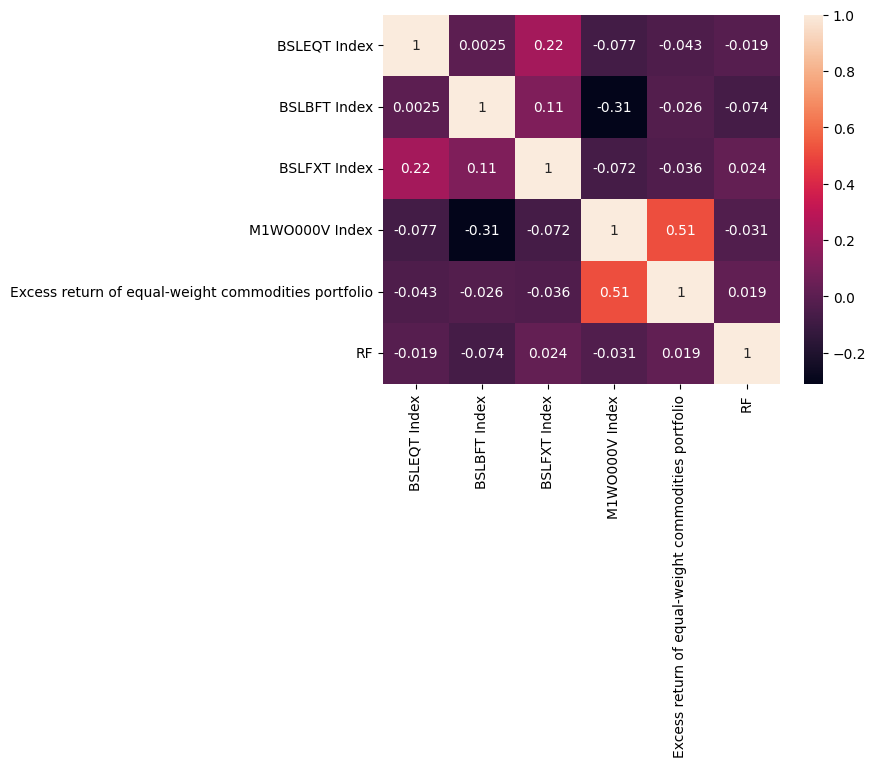

In [797]:
sns.heatmap(fret.corr(),annot=True)

In [798]:
reg_df = fret.copy()
reg_df['Macro-RF'] = ret - reg_df['RF']
reg_df.dropna(inplace=True)

In [799]:
y = reg_df['Macro-RF']
x = reg_df.drop(columns=['RF','Macro-RF'])

In [800]:
model = sm.OLS(y,sm.add_constant(x)).fit()
alpha = model.params['const'] * 12
print(f'Ann. alpha = {alpha:.2%}')
model.summary()

Ann. alpha = 8.89%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Macro-RF   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     35.75
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           7.01e-26
Time:                        12:11:02   Log-Likelihood:                 418.66
No. Observations:                 201   AIC:                            -825.3
Df Residuals:                     195   BIC:                            -805.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================================================
                                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
const                                                   0.0074      0.002      3.375      0.001       0.003       0.012
BSLEQT Index                                            0.4583      0.156      2.939      0.004       0.151       0.766
BSLBFT Index                                            0.8139      0.154      5.269      0.000       0.509       1.119
BSLFXT Index                                            0.6223      0.188      3.314      0.001       0.252       0.993
M1WO000V Index                                          0.1944      0.057      3.413      0.001       0.082       0.307
Excess return of equal-weight commodities portfolio     0.4490      0.059      7.565      0.000       0.332       0.566
==============================================================================
Omnibus:                       16.462   Durbin-Watson:                   1.814
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.199
Skew:                           0.166   Prob(JB):                     2.07e-11
Kurtosis:                       5.401   Cond. No.                         92.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [714]:
from
rols = RollingOLS(y,sm.add_constant(x),window=12*5).fit()
rols.params.drop(columns='const').plot()

SyntaxError: invalid syntax (2009582296.py, line 1)

<Axes: >

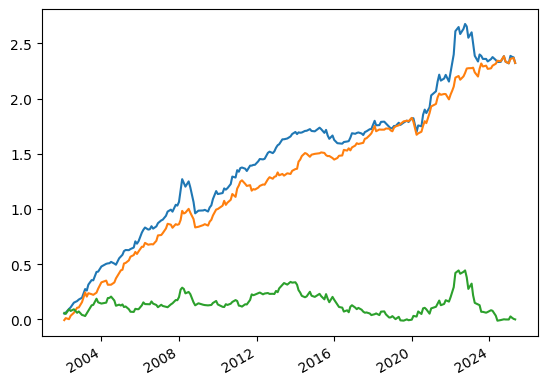

In [764]:
res = y - model.predict(sm.add_constant(x))
y.cumsum().plot()
model.predict(sm.add_constant(x)).cumsum().plot()
res.cumsum().plot()

<Axes: >

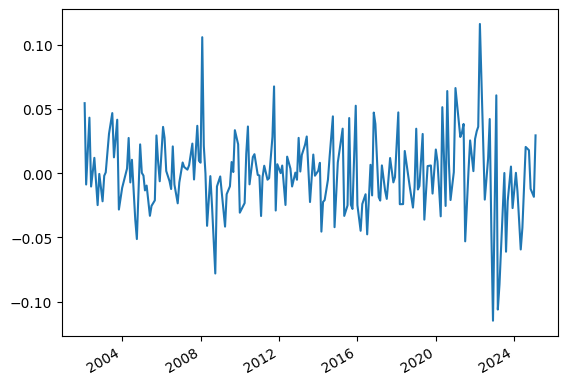

In [581]:
res.plot()

<Axes: xlabel='Date'>

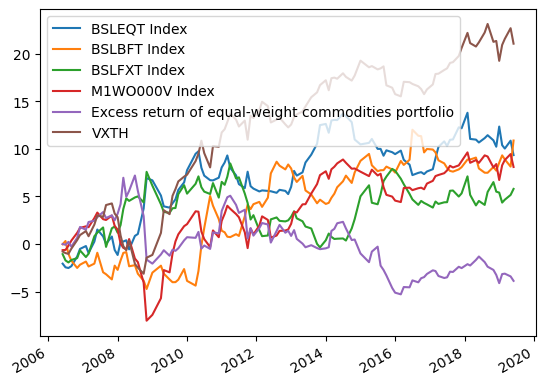

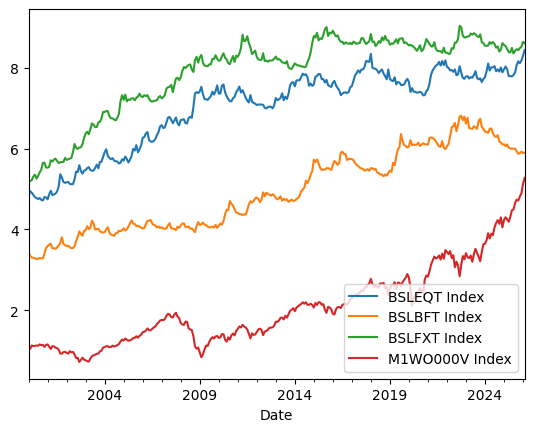

In [461]:
(x.div(x.std(),axis=1)).cumsum().plot()
(can_fac.div(can_fac.std(),axis=1)).plot()